In [12]:
import torch
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from types import SimpleNamespace
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting
from matplotlib import cm  # Colormaps
from matplotlib import gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib.ticker as mticker
torch.set_default_dtype(torch.float64)


plt.rcParams.update({'font.size': 22})
base_dir = os.getcwd()
save_dir = os.path.join(base_dir, "graphs")
output_data_ex3 = os.path.join(base_dir, "Experiment3_Magnetostatics", "optimisation", "output_data")

def load_run(data_dir, fname):
    """Load a results .npz file and return its arrays as torch tensors in a namespace."""
    raw = np.load(os.path.join(data_dir, fname), allow_pickle = True)
    ns = SimpleNamespace()
    for key in raw:
        try:
            setattr(ns, key, torch.tensor(raw[key]))
        except Exception:
            setattr(ns, key, raw[key])
    return ns

# Inverse problem

/tmp/ipykernel_287858/479523771.py:63: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(
/tmp/ipykernel_287858/479523771.py:67: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.stripplot(
/tmp/ipykernel_287858/479523771.py:63: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(
/tmp/ipykernel_287858/479523771.py:67: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.stripplot(
/tmp/ipykernel_287858/479523771.py:63: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(
/tmp/ipykernel_287858/479523771.py:67: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.stripplot(
/tmp/ipykernel_287858/479523771.py:63: UserWarning: The palette list has more values (4) than needed (2), 

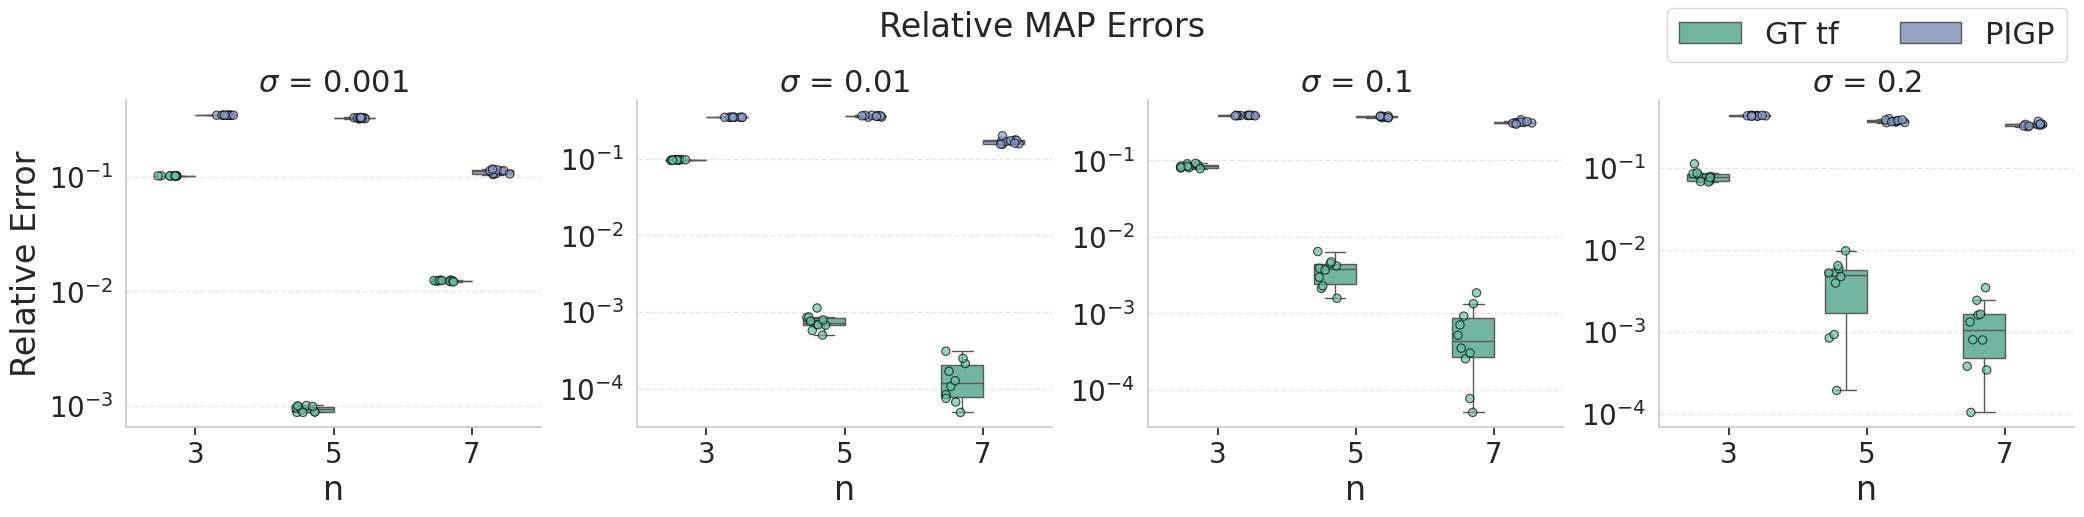

In [14]:
runs = 10
data_mode =["standard"]*2# ["extra_npoints_extra_sigma", "extra_npoints_extra_sigma"]#"standard" ]
sigma_list = [0.001, 0.01, 0.1, 0.2]
n_list = [3, 5, 7]#, 5, 10]#,  30, 50]
modes = ["GT", "PIGP"]
all_AE = np.zeros((len(n_list), len(sigma_list), len(modes), 1, runs))

for n_idx, npoints in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for j, mode in enumerate(modes):
            data_dir = os.path.join(output_data_ex3, data_mode[j])

            for run in range(runs):
                fname = f"Ex3_{mode}_n{npoints}_sigma{sigma:.3f}_{run}.npz"
                #try:
                data = load_run(data_dir, fname)
                
                all_AE[n_idx, sigma_idx, j, 0, run] = abs(data.nu0[-1] - 1)# data.peakmem_train - data.mem_baseline#(data.peakmem_eval - data.mem_baseline, #data.convergencetime#abs(data.nu0[-1] - 1)#data.n_iter#convergencetime
                #except:  pass
               


# --- reshape all_AE into long-form dataframe ---
records = []

display_n = ["3", "5", "7"]
for n_idx, n in enumerate(n_list):
    for sigma_idx, sigma in enumerate(sigma_list):
        for mode_idx, mode in enumerate(modes):
            for run in range(runs):
                ae = all_AE[n_idx, sigma_idx, mode_idx, 0, run]
                records.append({
                    "n": display_n[n_idx],
                    "sigma": sigma,
                    "mode": mode,
                    "data_mode": data_mode[mode_idx],
                    "AE": ae
                })

df = pd.DataFrame.from_records(records)

# categorical ordering
df["n"] = pd.Categorical(df["n"], categories=display_n, ordered=True)
df["sigma"] = pd.Categorical(df["sigma"], categories=sigma_list, ordered=True)
df["mode"] = pd.Categorical(df["mode"], categories=modes, ordered=True)
sns.set(style="whitegrid")

# --- plotting (exact same style as Ex2 inverse) ---
palette = sns.color_palette("Set2")[::2]


g = sns.FacetGrid(
    df,
    col="sigma",
    height=5.25,
    aspect=1.,
    sharey=False,
    margin_titles=False
)

def box_and_points(data, **kwargs):
    ax = plt.gca()
    sns.boxplot(
        data=data, x="n", y="AE", hue="mode",
        dodge=True, width=0.6, showfliers=False, palette=palette, ax=ax
    )
    sns.stripplot(
        data=data, x="n", y="AE", hue="mode",
        dodge=True, jitter=0.15, size=6, alpha=0.7, palette=palette,
        edgecolor='black',
        linewidth = 0.8, ax=ax
    )
    if ax.legend_ is not None:
        ax.legend_.remove()

g.map_dataframe(box_and_points)

# single legend
handles, labels = g.axes.flat[0].get_legend_handles_labels()
g.figure.legend(handles[:2], ["GT tf", "PIGP"], ncol=2, fontsize = 22, loc = (0.8, 0.88))#title="Mode"

# formatting: sigma in the subtitle (no parameter name)
nrows, ncols = g.axes.shape
for i in range(nrows):
    for j in range(ncols):
        ax = g.axes[i, j]
        
        ax.tick_params(axis="both", labelsize=20)
        ax.set_yscale("log")
        ax.grid(True, axis="y", linestyle="--", alpha=0.5)
        ax.set_title(rf"$\sigma$ = {g.col_names[j]}", fontsize=22)
        # keep x ticks on every panel, tick labels only on the bottom row
        ax.tick_params(axis="x", which="both", bottom=True, labelbottom=(i == nrows - 1))

g.set_axis_labels("n", "Relative Error", fontsize = 24)

g.figure.suptitle("Relative MAP Errors", fontsize=24)
g.figure.tight_layout()
#g.figure.subplots_adjust(top=0.90)

plt.savefig(os.path.join(save_dir, "Ex3_inverse_new.pdf"), bbox_inches="tight")


# Quiver plot

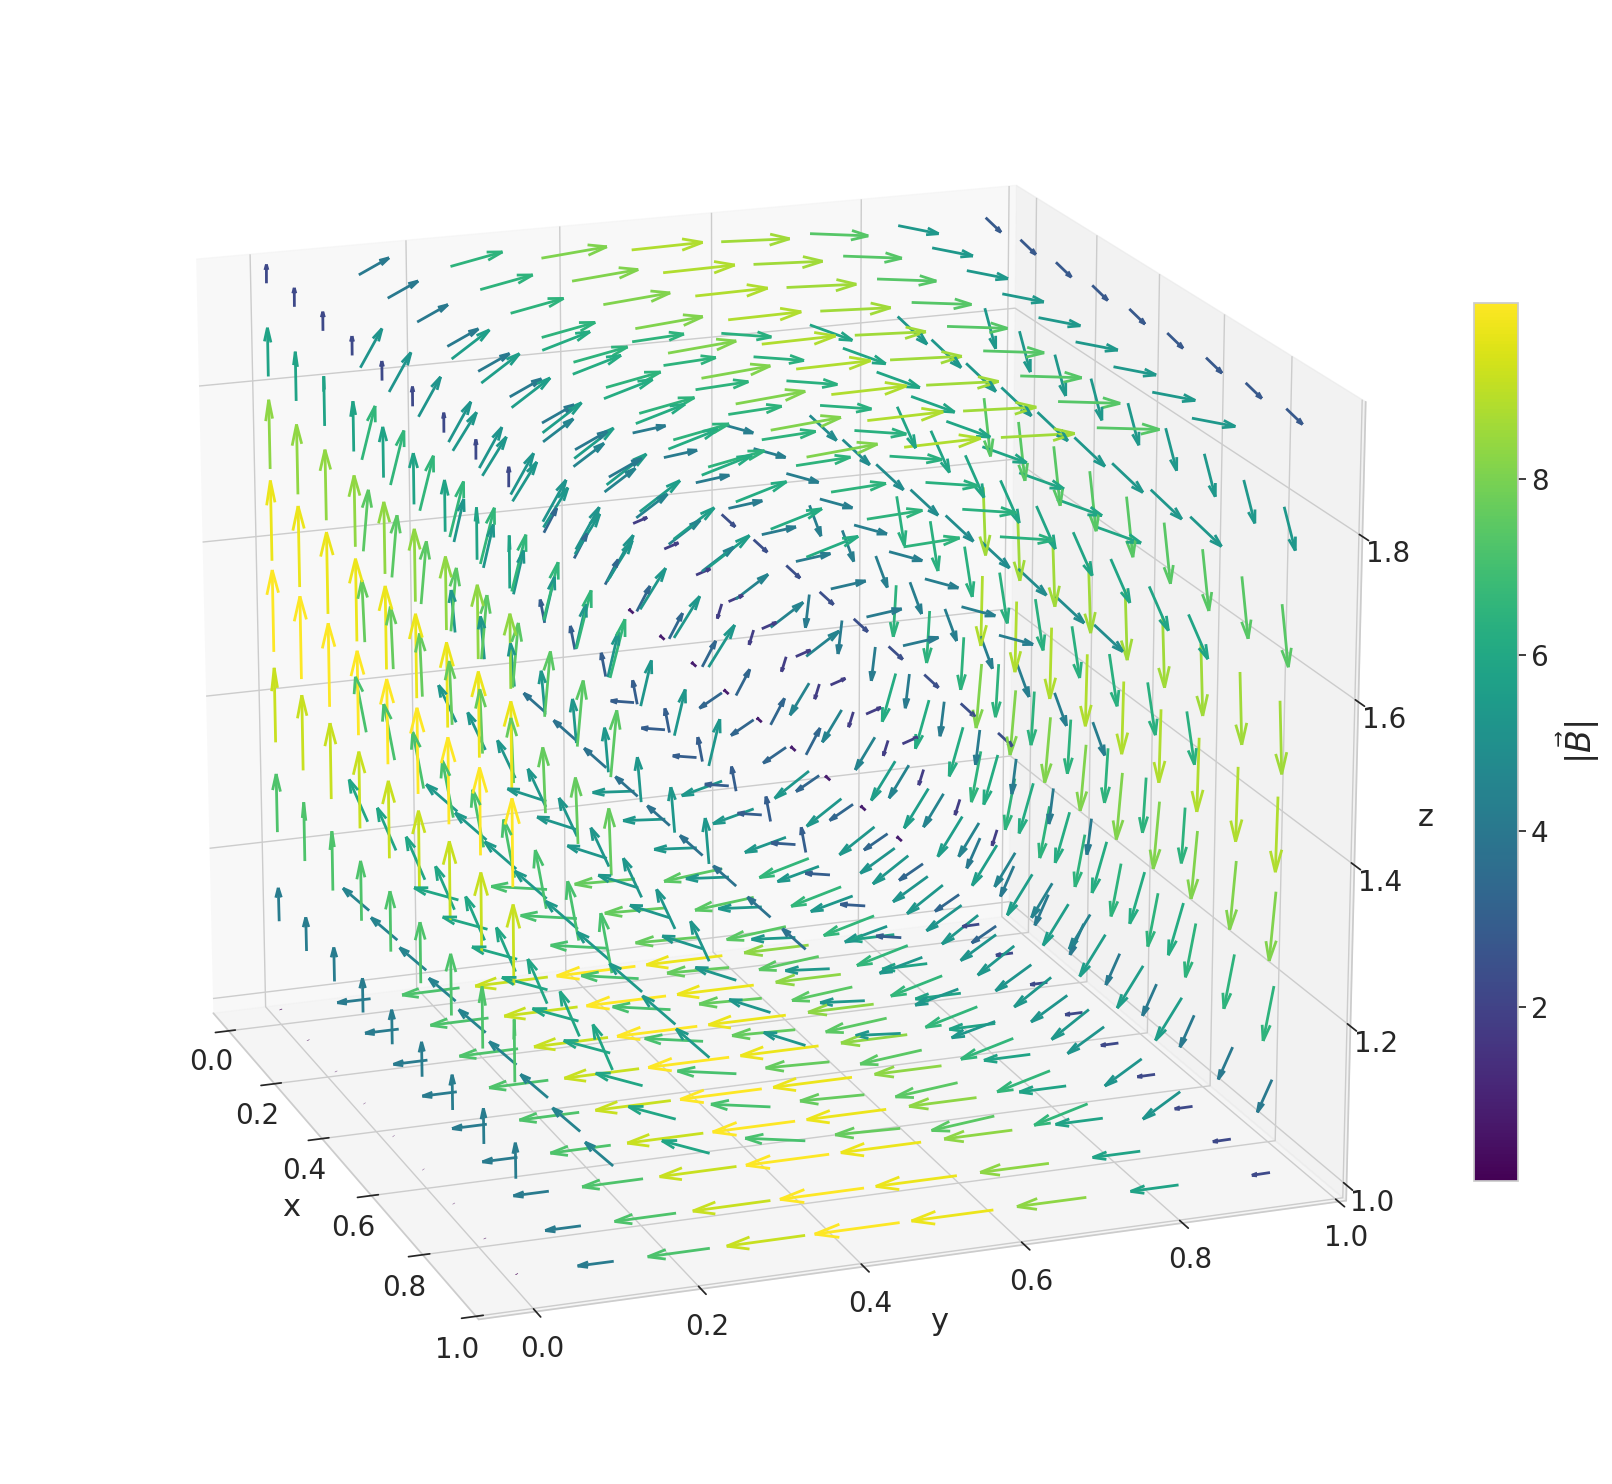

In [15]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3-D projection)
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize


def style_cbar(cbar, surf, n_ticks=5):
    #vmin, vmax = surf.get_clim()
    #ticks = np.linspace(vmin, vmax, n_ticks)
    #cbar.set_ticks(ticks)

    # Determine exponent
    #exp = int(np.floor(np.log10(max(abs(vmin), abs(vmax)))))
    #scale = 10**exp

    # Scale the tick labels
    cbar.ax.set_yticklabels([f"{t/scale:.1f}" for t in ticks])

    # Put 10^exp on top
    cbar.ax.set_title(rf"$10^{{{exp}}}$", fontsize = 20,  pad=-10)

    cbar.ax.tick_params(labelsize=20)

    
def plot_quiver_3d(X, Y, Z, U, V, W, title="Magnetic field B", stride=1,
                   cmap="viridis", equal_length=True):
    """3-D quiver of a vector field sampled on a regular cube.

    X, Y, Z, U, V, W : equally-shaped 3-D arrays (grid coordinates and the three
                       field components on that grid).
    stride           : subsample factor along each axis (stride=1 -> every grid
                       node, i.e. one arrow per point along each edge).
    equal_length     : True  -> all arrows drawn the same length (a direction map;
                               magnitude is shown by colour only). Best when |B|
                               spans orders of magnitude, otherwise weak arrows
                               vanish across most of the cube.
                       False -> arrow length is proportional to |B|.
    Arrows are always coloured by |B|, one uniform colour per arrow.
    """
    sl = (slice(None, None, stride),) * 3
    X, Y, Z = X[sl], Y[sl], Z[sl]
    U, V, W = U[sl], V[sl], W[sl]

    mag = np.sqrt(U**2 + V**2 + W**2)
    spacing = min(np.diff(np.unique(a))[0] for a in (X, Y, Z) if np.unique(a).size > 1)
    if equal_length:
        length, normalize = 0.9 * spacing, True
    else:
        length, normalize = 0.9 * spacing / mag.max(), False

    # One uniform colour per arrow. mpl's 3-D quiver assembles the Line3DCollection
    # as [shafts (N), side-0 heads (N), side-1 heads (N)], every block in the same
    # arrow order, so the per-arrow colour is simply tiled 3x (NOT interleaved).
    norm = Normalize(vmin=float(mag.min()), vmax=float(mag.max()))
    base = plt.get_cmap(cmap)(norm(mag.ravel()))
    colors = np.tile(base, (3, 1))

    fig = plt.figure(figsize=(21, 15))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.quiver(X, Y, Z, U, V, W, length=length, normalize=normalize,
              colors=colors, linewidth=2.0)
    ax.set_xlabel("x", labelpad=10)
    ax.set_ylabel("y", labelpad=10)
    ax.set_zlabel("z", labelpad=10)
    ax.set_title(title, fontsize=22)

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar =  fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.)#, label="|B|", fontsize = 22)
    cbar.ax.tick_params(labelsize=20)
    cbar.set_label(r"$|\vec{B}|$", fontsize=24)
    #style_cbar(cbar, None)
    fig.tight_layout()
    return fig, ax


# ── forward GT problem: magnetic field B = (Bx, By, Bz) = last 3 tasks ─────────
# GT tasks: ["Ax", "Ay", "Az", "J", "GT", "Bx", "By", "Bz"]  →  Bx,By,Bz = 5,6,7
data_dir = os.path.join(output_data_ex3, "forward")
data = load_run(data_dir, "Ex3_GT.npz")

test_n = 18                      # test grid is an 18x18x18 cube
B_tasks = [5, 6, 7]

# grid coordinates (identical for every task) taken straight from test_x
pos = data.test_x[data.test_x[:, -1] == B_tasks[0], :3]
pos = pos.reshape(test_n, test_n, test_n, 3).numpy()
X, Y, Z = pos[..., 0], pos[..., 1], pos[..., 2]

U = data.mean[data.test_x[:, -1] == 5].reshape(test_n, test_n, test_n).numpy()
V = data.mean[data.test_x[:, -1] == 6].reshape(test_n, test_n, test_n).numpy()
W = data.mean[data.test_x[:, -1] == 7].reshape(test_n, test_n, test_n).numpy()

fig, ax = plot_quiver_3d(X, Y, Z, U, V, W,
                         title=None,#"Forward GT — magnetic field over the cube",
                         stride=2, equal_length=False)
ax.view_init(elev=18, azim=-20)   # face more of the y-z plane (look down the x-axis)
ax.set_xlabel("x", fontsize=22)
ax.set_ylabel("y", fontsize=22)
ax.set_zlabel("z", fontsize=22)
ax.set_aspect("equal")
ax.tick_params(axis="both", labelsize=20)





plt.savefig(os.path.join(save_dir, "Ex3_quiver_GT.pdf"), bbox_inches="tight")


# Forward plot

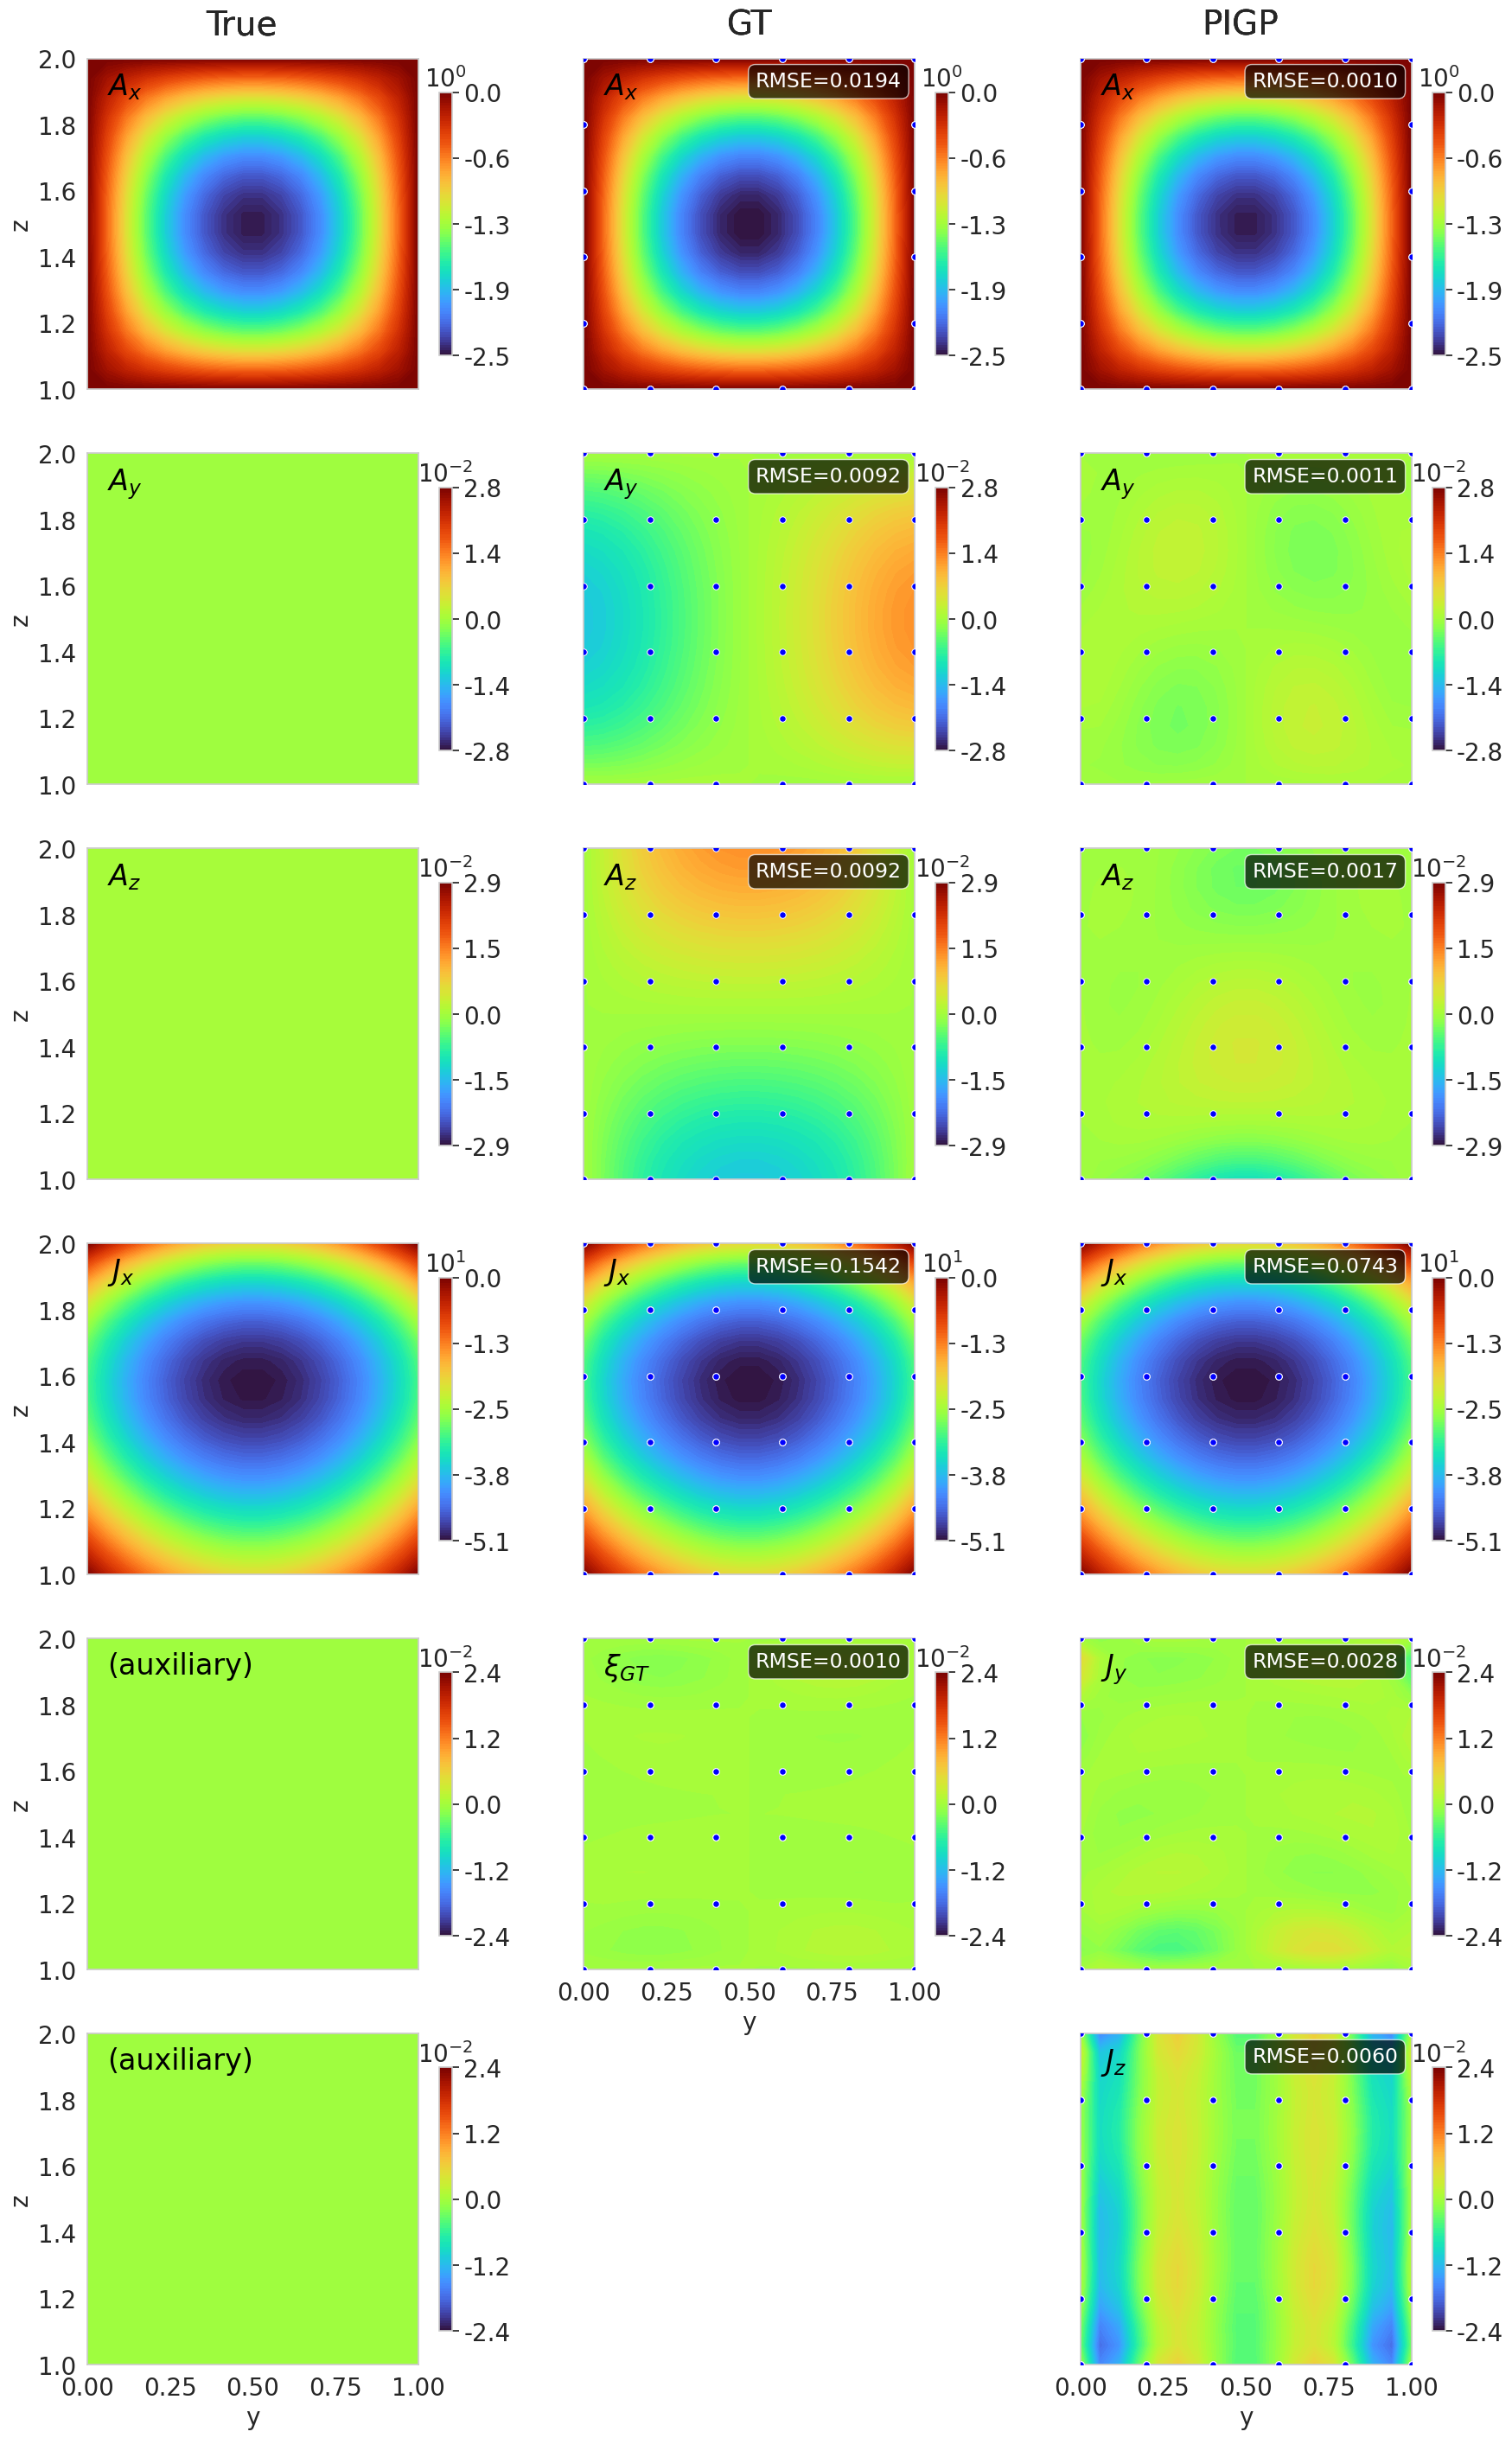

In [21]:

def style_cbar(cbar, surf, n_ticks=5):
    vmin, vmax  = surf.get_clim()

    ticks = np.linspace(vmin, vmax, n_ticks)
    cbar.set_ticks(ticks)

    # Determine exponent
    exp = int(np.floor(np.log10(max(abs(vmin), abs(vmax)))))
    scale = 10**exp

    # Scale the tick labels
    cbar.ax.set_yticklabels([f"{t/scale:.1f}" for t in ticks])

    # Put 10^exp on top
    cbar.ax.set_title(rf"$10^{{{exp}}}$", fontsize = 20,  pad=-10)

    cbar.ax.tick_params(labelsize=20)

# per-subplot cell size in inches; shared with the PIGP cell so panels in both
# figures come out exactly the same size (figsize = n_cols/rows * cell size)
CELL_W, CELL_H = 5.0, 4.3

data_dir = os.path.join(output_data_ex3, "forward")
mode = "GT"
npoints = 5
sigma = 0.1

fig = plt.figure(figsize=(21, 32), constrained_layout = False)
nrows, ncols = 6, 3
#fig, ax = plt.subplots(nrows, ncols, figsize=(ncols * CELL_W, nrows * CELL_H))
#print("used training points", data.train_y.shape)

test_n = 18
xxx = torch.linspace(0, 1, test_n)
yyy = torch.linspace(0, 1, test_n)
zzz = torch.linspace(1, 2, test_n)
tx, ty, tz = torch.meshgrid(xxx, yyy, zzz, indexing="ij")

# put the slice on the test node closest to a training x-layer, so the training
# points actually lie in the visible y-z plane (solution has no x-dependence)

#for visualizations:
# collect the datasets
datasets = {}
xes = {}
for mode in ["True", "GT", "PIGP"]:
    if mode == "True":
        data = load_run(data_dir, "Ex3_PIGP.npz")
        datasets[mode] = data.test_y
        xes[mode] = data.test_x
    else:
        data = load_run(data_dir, f"Ex3_{mode}.npz")
        datasets[mode] = data.mean
        xes[mode] = data.test_x

# common limits for each row (task)
row_limits = {}

for i in range(6):
    vals = []
    for mode in ["True", "GT", "PIGP"]:
        mask = xes[mode][:,-1] == i
        vals.append(np.asarray((datasets[mode])[mask]))
    vals = np.concatenate(vals)
    if i==0 or i == 3:
        row_limits[i] = (vals.min(), vals.max())

    else:
        vex = max(abs(vals.min()), abs(vals.max()))
        row_limits[i] =(-vex, vex)
    
for j in range(3):
    if j == 0:
        mode = "True"
        title = [r"$A_x$", r"$A_y$", r"$A_z$", r"$J_x$", "(auxiliary)", "(auxiliary)"]
        fname =  f"Ex3_PIGP.npz"
        data = load_run(data_dir, fname)
        to_plot = data.test_y
        i_lim = 6
    elif j == 1:
        mode = "GT"
        title = [r"$A_x$", r"$A_y$", r"$A_z$", r"$J_x$", r"$\xi_{GT}$"]
        
        fname =  f"Ex3_{mode}.npz"
        data = load_run(data_dir, fname)
        to_plot = data.mean
        i_lim = 5
    else:
        mode = "PIGP"
        title = [r"$A_x$", r"$A_y$", r"$A_z$", r"$J_x$", r"$J_y$", r"$J_z$"]                
        fname =  f"Ex3_{mode}.npz"
        data = load_run(data_dir, fname)
        to_plot = data.mean
        i_lim = 6
    fig.subplots_adjust(top=0.96)
    fig.text(0.21, 0.97, "True", ha="center", va="top", fontsize=28)
    fig.text(0.49, 0.97, "GT",   ha="center", va="top", fontsize=28)
    fig.text(0.76, 0.97, "PIGP", ha="center", va="top", fontsize=28)
    for i in range(i_lim):
        train_layers = torch.unique(data.train_x[:, 0])
        x_near = float(train_layers[(train_layers - float(xxx[test_n // 2])).abs().argmin()])
        x_idx = int((xxx - x_near).abs().argmin())
        X = ty[x_idx, :, :]
        Y = tz[x_idx, :, :]
        grid = gridspec.GridSpec(6, 3, figure=fig, hspace=0.05)
        if i == 0:
             first_ax = fig.add_subplot(grid[i, j])#, sharex=first_ax)#
             a = first_ax
            
        else:
            a = fig.add_subplot(grid[i, j], sharex=first_ax)#a = ax[i, j]
        mask = data.test_x[:, -1] == i
    
        Z = to_plot[mask].reshape(test_n, test_n, test_n)[x_idx, :, :]
        vmin, vmax = row_limits[i]
        levels = np.linspace(vmin, vmax, 101)

        cf = a.contourf(X, Y, Z, levels=levels, cmap="turbo", vmin = vmin, vmax = vmax)
        cbar = fig.colorbar(cf, ax=a, shrink=0.7)
        
        style_cbar(cbar, cf)#, vmin = vmin, vmax = vmax)
        #a.set_title(title[i], fontsize=24)
        a.text(0.06, 0.96, title[i], transform=a.transAxes, fontsize = 24, color = "black", ha="left", va="top")
                 #  bbox=dict(boxstyle="round,pad=0.35", fc="black", alpha=0.7))
        # training points lying in the visible slice (B-field tasks have none)
        tmask = (data.train_x[:, -1] == i)# & ((data.train_x[:, 0] - x_near).abs() < 1e-6)
        #if bool(tmask.any()):
        if j>0:
            a.scatter(data.train_x[tmask, 1], data.train_x[tmask, 2],
                      color="blue", edgecolors="white", linewidths=0.6, s=28, zorder=3)
    
        a.set_box_aspect(1)
       # if i == i_lim-1:
        
        if i == i_lim - 1:
            a.set_xlabel("y", fontsize=20)
            a.tick_params(labelsize=20)
        else:
            a.tick_params(labelbottom=False, labelsize=20)#bottom=False, 
        if j>0:
            a.tick_params(labelleft=False, labelsize=20)#left=False, 
        if j == 0:
            a.set_ylabel("z", fontsize=20)
        # per-task RMSE annotation (more readable: larger font, opaque box)
        rmse = float(np.sqrt(((np.asarray(data.mean[mask]) - np.asarray(data.test_y[mask]))**2).mean()))
        if j>0:
            a.text(0.96, 0.96, f"RMSE={rmse:.4f}", transform=a.transAxes,
                   ha="right", va="top", fontsize=17, color="white",
                   bbox=dict(boxstyle="round,pad=0.35", fc="black", alpha=0.7))
plt.savefig(os.path.join(save_dir, "Ex3_forward_auxiliary.pdf"), bbox_inches="tight")


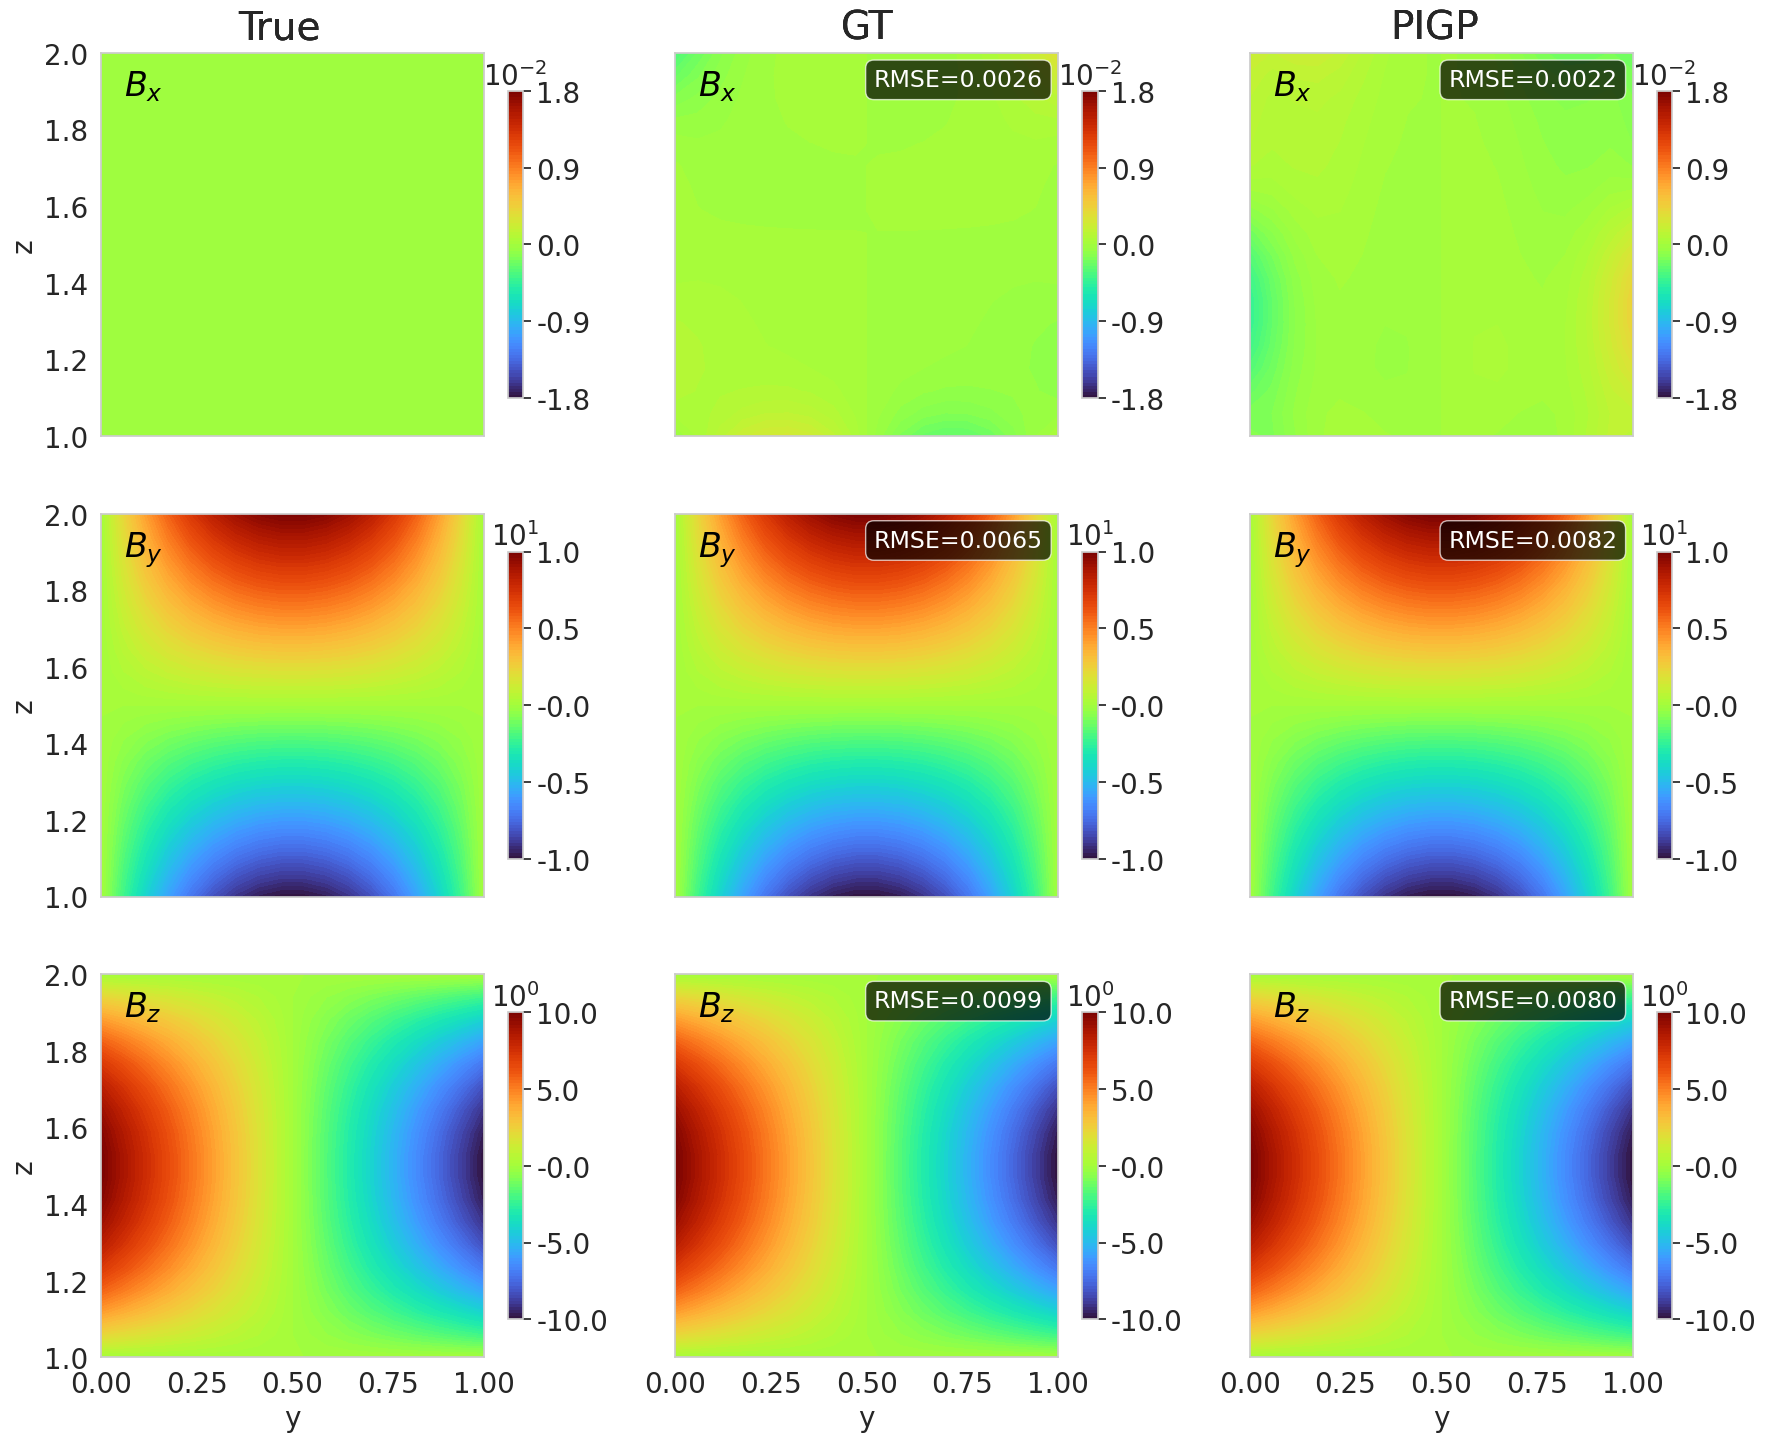

In [19]:
data_dir = os.path.join(output_data_ex3, "forward")
npoints = 5
sigma = 0.1

fig = plt.figure(figsize=(21, 16), constrained_layout = False)
nrows, ncols = 3, 3


test_n = 18
xxx = torch.linspace(0, 1, test_n)
yyy = torch.linspace(0, 1, test_n)
zzz = torch.linspace(1, 2, test_n)
tx, ty, tz = torch.meshgrid(xxx, yyy, zzz, indexing="ij")



#for visualizations:
datasets = {}
xes = {}
for mode in ["True", "GT", "PIGP"]:
    if mode == "True":
        data = load_run(data_dir, "Ex3_PIGP.npz")
        datasets[mode] = data.test_y
        xes[mode] = data.test_x
    else:
        data = load_run(data_dir, f"Ex3_{mode}.npz")
        datasets[mode] = data.mean
        xes[mode] = data.test_x


row_limits = {}
i_lim = {"True": 6, "GT": 5, "PIGP": 6}
for i in range(3):
    vals = []
    for mode in ["True", "GT", "PIGP"]:
        mask = xes[mode][:,-1] == i_lim[mode]+i
        vals.append(np.asarray((datasets[mode])[mask]))
    vals = np.concatenate(vals)
    row_limits[i] = (vals.min(), vals.max())
for j in range(3):
    if j == 0:
        mode = "True"
        title = [r"$B_x$", r"$B_y$", r"$B_z$", r"$J_x$", "(auxiliary)", "(auxiliary)"]
        fname =  f"Ex3_PIGP.npz"
        data = load_run(data_dir, fname)
        to_plot = data.test_y
        i_lim = 6
    elif j == 1:
        mode = "GT"
        title = [r"$B_x$", r"$B_y$", r"$B_z$", r"$J_x$", r"$\xi_{GT}$"]
        
        fname =  f"Ex3_{mode}.npz"
        data = load_run(data_dir, fname)
        to_plot = data.mean
        i_lim = 5
    else:
        mode = "PIGP"
        title = [r"$B_x$", r"$B_y$", r"$B_z$", r"$J_x$", r"$J_y$", r"$J_z$"]                
        fname =  f"Ex3_{mode}.npz"
        data = load_run(data_dir, fname)
        to_plot = data.mean
        i_lim = 6
    fig.subplots_adjust(top=0.96)
    fig.text(0.21, 0.97, "True", ha="center", va="top", fontsize=28)
    fig.text(0.49, 0.97, "GT",   ha="center", va="top", fontsize=28)
    fig.text(0.76, 0.97, "PIGP", ha="center", va="top", fontsize=28)
    for i in range(i_lim, i_lim+3):
        train_layers = torch.unique(data.train_x[:, 0])
        x_near = float(train_layers[(train_layers - float(xxx[test_n // 2])).abs().argmin()])
        x_idx = int((xxx - x_near).abs().argmin())
        X = ty[x_idx, :, :]
        Y = tz[x_idx, :, :]
        grid = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.05)
        if i == 0:
             first_ax = fig.add_subplot(grid[i-i_lim, j])#, sharex=first_ax)#
             a = first_ax
        else:
            a = fig.add_subplot(grid[i-i_lim, j], sharex=first_ax)#a = ax[i, j]
        mask = data.test_x[:, -1] == i
    
        Z = to_plot[mask].reshape(test_n, test_n, test_n)[x_idx, :, :]
    
        vmin, vmax = row_limits[i-i_lim]
        levels = np.linspace(vmin, vmax, 101)

        cf = a.contourf(X, Y, Z, levels=levels, cmap="turbo", vmin = vmin, vmax = vmax)
        cbar = fig.colorbar(cf, ax=a, shrink=0.7)
        style_cbar(cbar, cf)
        #a.set_title(title[i], fontsize=24)
        a.text(0.06, 0.96, title[i-i_lim], transform=a.transAxes, fontsize = 24, color = "black", ha="left", va="top")
                
        # training points lying in the visible slice (B-field tasks have none)
        tmask = (data.train_x[:, -1] == i)# & ((data.train_x[:, 0] - x_near).abs() < 1e-6)
        if j>0:
            a.scatter(data.train_x[tmask, 1], data.train_x[tmask, 2],
                      color="blue", edgecolors="white", linewidths=0.6, s=28, zorder=3)
    
        a.set_box_aspect(1)
        if i == i_lim +2:
            a.set_xlabel("y", fontsize=20)
            a.tick_params(labelsize=20)
        else:
            a.tick_params(labelbottom=False, labelsize=20)#bottom=False, 
        if j>0:
            a.tick_params(labelleft=False, labelsize=20)#left=False, 
        if j == 0:
            a.set_ylabel("z", fontsize=20)
        # per-task RMSE annotation (more readable: larger font, opaque box)
        rmse = float(np.sqrt(((np.asarray(data.mean[mask]) - np.asarray(data.test_y[mask]))**2).mean()))
        if j>0:
            a.text(0.96, 0.96, f"RMSE={rmse:.4f}", transform=a.transAxes,
                   ha="right", va="top", fontsize=17, color="white",
                   bbox=dict(boxstyle="round,pad=0.35", fc="black", alpha=0.7))
plt.savefig(os.path.join(save_dir, "Ex3_forward_B.pdf"), bbox_inches="tight")


# Posterior Grid evaluation

/tmp/ipykernel_287858/786617811.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[0].plot(data.nu0_vals, -np.log(-prior + max(prior) + 1), style[mode], label = mode+r", $\sigma = $%.3f"%sigma)
/tmp/ipykernel_287858/786617811.py:25: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[1].plot(data.nu0_vals, -np.log(-dataterm + max(dataterm) + 1), style[mode], label = mode+r", $\sigma = $%.3f"%sigma)
/tmp/ipykernel_287858/786617811.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax[2].plot(data.nu0_vals, -np.log(-mll + max(mll) + 1), style[mode], label = mode+r", $\sigma = $%.3f"%sigma)


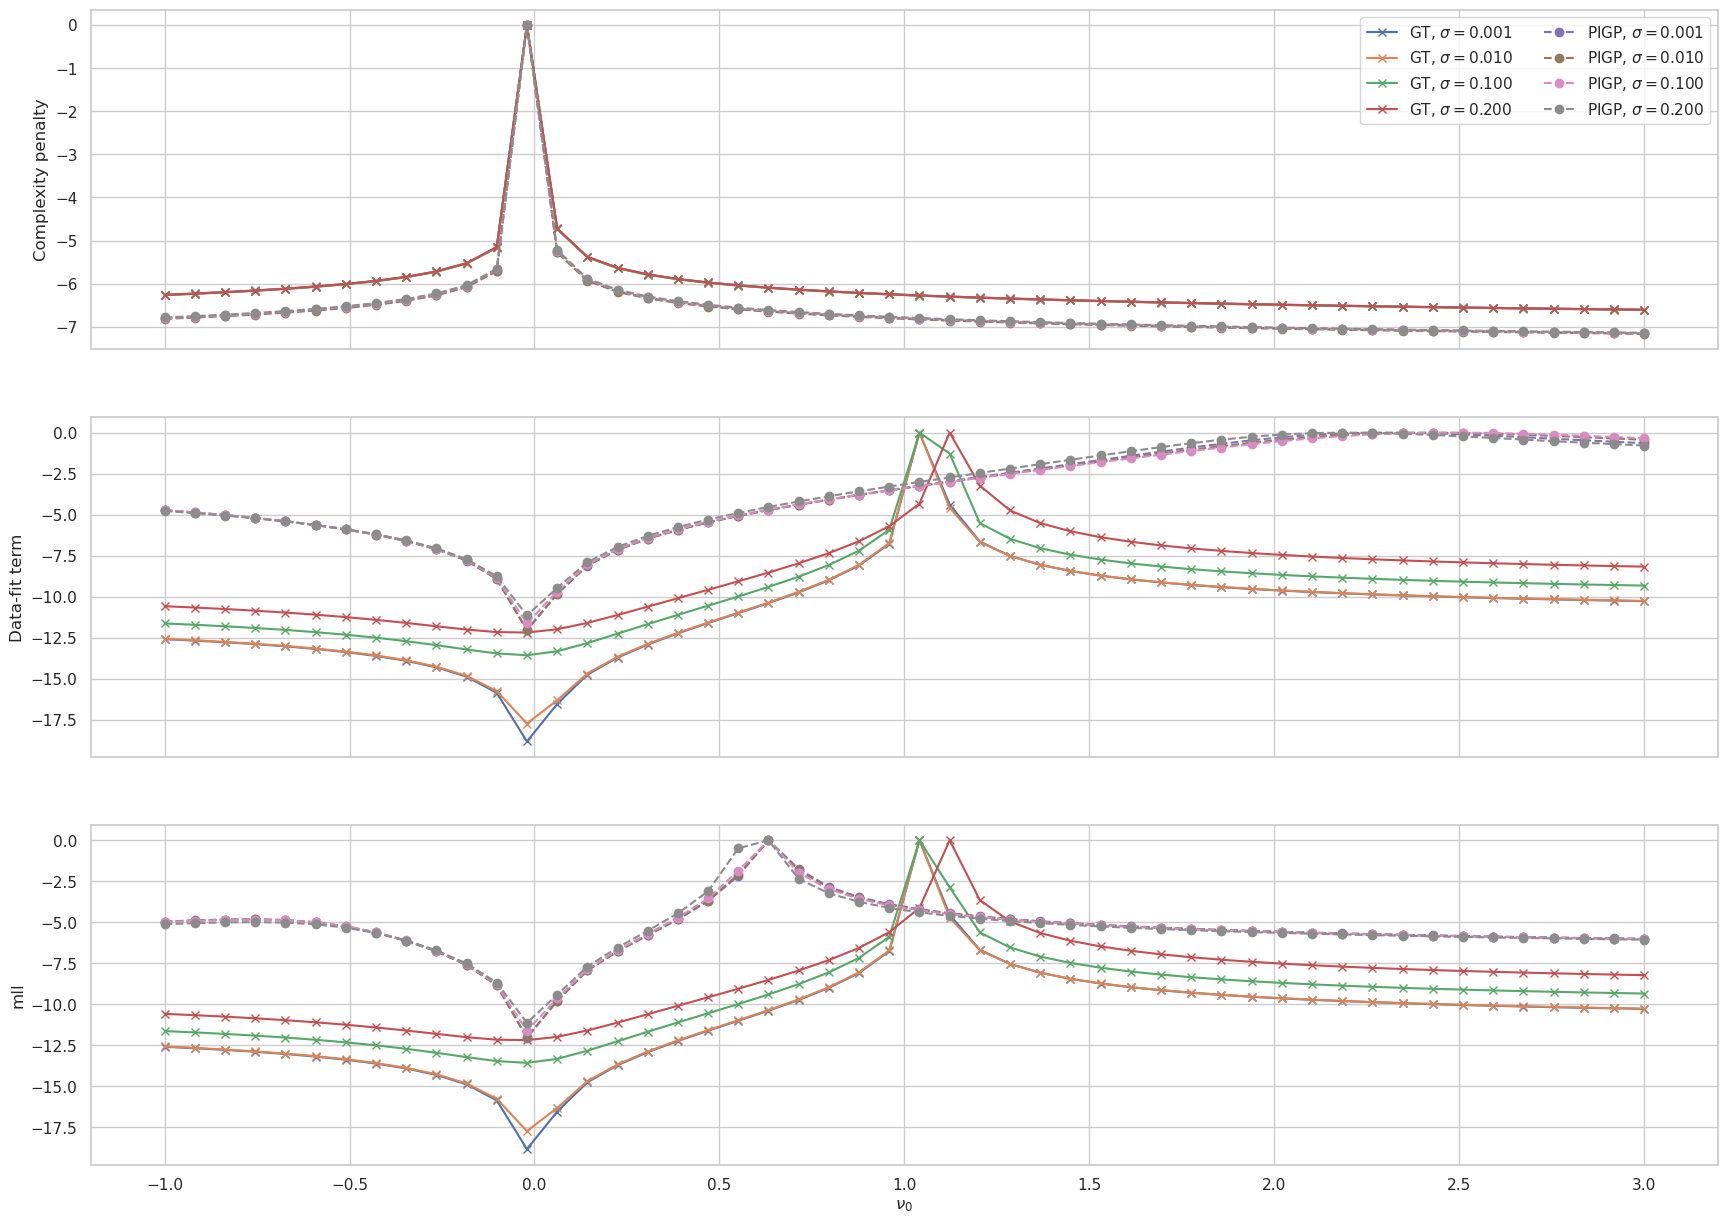

In [20]:
from scipy.special import logsumexp

grid_data = os.path.join(base_dir, "Experiment3_Magnetostatics", "grid_evaluation", "output_data")
data_dir = os.path.join(grid_data, "extra_npoints_extra_sigma")
style = {"PIGP":"o--", "GT":"x-"}
fig, ax = plt.subplots(3, 1, figsize=(21, 15), sharex = True)
npoints = 3

for mode in ["GT", "PIGP"]:
    for sigma in [0.001, 0.01, 0.1, 0.2]:
        fname = f"{mode}_prior_sigma{sigma:.3f}.npz"#
        data = load_run(data_dir, fname)
        prior = data.log_prior
        ax[0].plot(data.nu0_vals, -np.log(-prior + max(prior) + 1), style[mode], label = mode+r", $\sigma = $%.3f"%sigma)
        ax[0].set_ylabel("Complexity penalty")
        
        fname = f"{mode}_n{npoints}_sigma{sigma:.3f}_dataterm.npz"#
        data = load_run(data_dir, fname)
        dataterm = data.dataterm_values
        ax[1].plot(data.nu0_vals, -np.log(-dataterm + max(dataterm) + 1), style[mode], label = mode+r", $\sigma = $%.3f"%sigma)
        ax[1].set_ylabel("Data-fit term")
        
        mll = dataterm + prior
        ax[2].plot(data.nu0_vals, -np.log(-mll + max(mll) + 1), style[mode], label = mode+r", $\sigma = $%.3f"%sigma)
        ax[2].set_ylabel("mll")
    plt.xlabel(r"$\nu_0$")
    ax[0].legend(ncols = 2)
plt.savefig(os.path.join(save_dir, "Ex3_posterior.pdf"))